Generate, experiment with results across runs

In [11]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Filter

In [12]:
RUNS_DIR = "../runs"  # notebook sits one level below the project root

# Line chart: rounds are grouped into consecutive windows of this size and averaged
AVG_WINDOW = 100

# Unit shown on the energy axis (change if your simulator uses something else)
ENERGY_UNIT = "J"

# Filenames look like runs/{YYYYMMDDHH}_{seed}_{algo}.csv
# Datetime filters may be written with or without dashes, and can be partial
# (e.g. "2026-09-30" = from/until that day).
START_DATETIME="0000-00-00-00"
END_DATETIME="9999-99-99-99"

# None = average over every seed; or set an int to look at a single seed
SEED=None

Load runs

In [13]:
def find_csvs(runs_dir=RUNS_DIR, max_depth=3):
    """Find the folder holding the run csvs no matter where the notebook is opened from.
    Order: (1) an absolute RUNS_DIR as given, (2) `runs_dir` in the working directory and
    every parent folder above it, (3) any folder named `runs_dir` up to `max_depth` levels
    below the working directory or below any parent."""
    def csvs_in(folder):
        return sorted(
            str(p) for p in Path(folder).rglob("*") if p.is_file() and p.suffix.lower() == ".csv"
        )

    cwd = Path.cwd().resolve()
    candidates = []
    if Path(runs_dir).is_absolute():
        candidates.append(Path(runs_dir))
    for base in [cwd, *cwd.parents]:                     # walk up
        candidates.append(base / runs_dir)
    for base in [cwd, *cwd.parents]:                     # then look down
        for depth in range(1, max_depth + 1):
            candidates.extend(
                d for d in base.glob("/".join(["*"] * (depth - 1) + [Path(runs_dir).name]))
                if d.is_dir()
            )

    seen = set()
    for cand in candidates:
        cand = cand.resolve()
        if cand in seen or not cand.is_dir():
            continue
        seen.add(cand)
        paths = csvs_in(cand)
        if paths:
            return str(cand), paths

    raise FileNotFoundError(
        f"No csv files found. Working directory: {cwd}\n"
        f"Searched for a '{runs_dir}' folder above and below it. "
        f"Set RUNS_DIR to the absolute path of the folder run.py writes to."
    )


def load_runs(runs_dir=RUNS_DIR, start=START_DATETIME, end=END_DATETIME, seed=SEED):
    runs_dir, paths = find_csvs(runs_dir)
    print(f"Reading {len(paths)} csv file(s) from {os.path.abspath(runs_dir)}")
    start_key = start.replace("-", "").ljust(10, "0")
    end_key = end.replace("-", "").ljust(10, "9")

    runs, skipped = [], []
    for path in paths:
        name = os.path.basename(path)
        stem = os.path.splitext(name)[0]
        parts = stem.split("_", 2)  # algo name may itself contain "_"
        if len(parts) != 3 or not parts[1].lstrip("-").isdigit():
            skipped.append((name, "filename doesn't match {datetime}_{seed}_{algo}.csv"))
            continue
        dt, run_seed, algo = parts
        if not (start_key <= dt <= end_key):
            skipped.append((name, f"datetime {dt} outside [{start_key}, {end_key}]"))
            continue
        if seed is not None and int(run_seed) != int(seed):
            skipped.append((name, f"seed {run_seed} != SEED={seed}"))
            continue
        runs.append(dict(algo=algo, seed=int(run_seed), datetime=dt, history=pd.read_csv(path)))

    if not runs:
        msg = [f"No runs matched. Looked in {os.path.abspath(runs_dir)}: {len(paths)} csv file(s) found."]
        msg += [f"  skipped {n}: {why}" for n, why in skipped]
        raise ValueError("\n".join(msg))
    return runs


runs = load_runs()
ALGOS = list(dict.fromkeys(r["algo"] for r in runs))  # keep first-seen order

summary = pd.DataFrame(
    [dict(algo=r["algo"], seed=r["seed"], datetime=r["datetime"], lifespan=len(r["history"]))
     for r in runs]
)
print(f"{len(runs)} runs, seeds: {sorted(summary['seed'].unique())}")
summary.groupby("algo").size().reindex(ALGOS).rename("runs")

Reading 4 csv file(s) from C:\Users\LOQ\Desktop\uwsn\runs
4 runs, seeds: [np.int64(0), np.int64(19), np.int64(28)]


algo
AC-ACO     1
NodeACO    2
PSO        1
Name: runs, dtype: int64

Lifespan (rounds survived): mean ± std across runs

,mean,std,min,max,count
algo,,,,,
AC-ACO,2195.0,0.000000,2195,2195,1
NodeACO,2132.0,8.485281,2126,2138,2
PSO,2306.0,0.000000,2306,2306,1


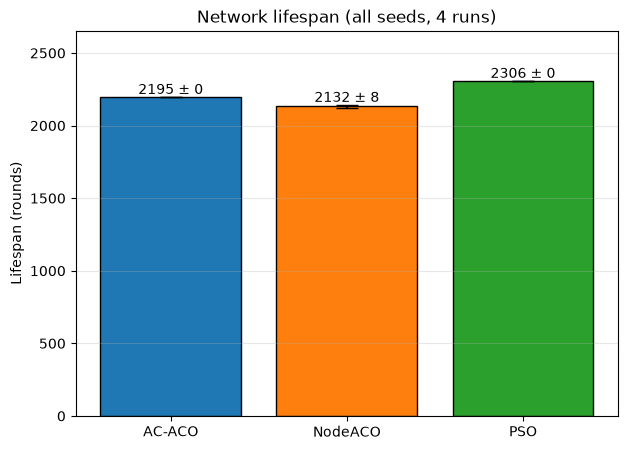

In [14]:
stats = (
    summary.groupby("algo")["lifespan"]
    .agg(["mean", "std", "min", "max", "count"])
    .reindex(ALGOS)
)
stats["std"] = stats["std"].fillna(0)  # a single run has no spread
display(stats)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    stats.index, stats["mean"], yerr=stats["std"],
    capsize=8, color=plt.cm.tab10(range(len(stats))), edgecolor="black",
)
for bar, m, s in zip(bars, stats["mean"], stats["std"]):
    ax.text(bar.get_x() + bar.get_width() / 2, m + s, f"{m:.0f} ± {s:.0f}",
            ha="center", va="bottom")

seed_label = "all seeds" if SEED is None else f"seed {SEED}"
ax.set_ylabel("Lifespan (rounds)")
ax.set_title(f"Network lifespan ({seed_label}, {len(runs)} runs)")
ax.margins(y=0.15)
ax.grid(axis="y", alpha=0.3)
plt.show()

Average round energy across rounds

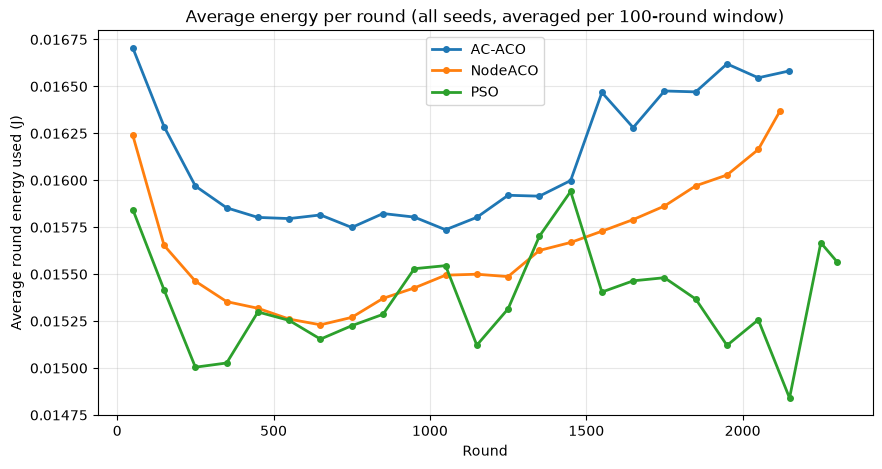

In [15]:
def mean_energy_curve(algo):
    series = [r["history"]["round_energy"].to_numpy() for r in runs if r["algo"] == algo]
    length = max(len(s) for s in series)
    padded = np.full((len(series), length), np.nan)
    for i, s in enumerate(series):
        padded[i, : len(s)] = s  # runs that died earlier stay NaN afterwards
    return np.nanmean(padded, axis=0)


def window_average(curve, window=AVG_WINDOW):
    """Average each consecutive block of `window` rounds; returns (block centers, block means)."""
    starts = np.arange(0, len(curve), window)
    means = np.array([curve[s : s + window].mean() for s in starts])
    centers = starts + np.array([len(curve[s : s + window]) for s in starts]) / 2
    return centers, means


fig, ax = plt.subplots(figsize=(10, 5))
for algo in ALGOS:
    x, y = window_average(mean_energy_curve(algo))
    ax.plot(x, y, marker="o", markersize=4, linewidth=2, label=algo)

ax.set_xlabel("Round")
ax.set_ylabel(f"Average round energy used ({ENERGY_UNIT})")
ax.set_title(f"Average energy per round ({seed_label}, averaged per {AVG_WINDOW}-round window)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()